#### Vizualization of log-likelihood deltas between anchor and augmented reponse ... this time with bins ... and with llama gen responses

This jupyter notebooks repeats the experiments from `/u/rfechner/verl/workspace/plots/exp03_exp06_vizualizations_delta_logprobs_bins.ipynb` but we're taking the logprobabilities calculated for responses generated by llama instead of qwen3.

### Error Behaviour Analysis

I'm skipping this here, because we didn't generate anything for the errors.

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
# get the timings per checkpoint interval of each method (taken straight from logs):
save_freq = 10
timings = {
    "llama_3.2_1b_instruct__grpo" : 356 * save_freq,
    "llama_3.2_1b_instruct__kl-cov" : 2168 * save_freq,
    "llama_3.2_1b_instruct__grpo-s" : 351 * save_freq,
}

In [3]:
import matplotlib.pyplot as plt

### Reasoning Type Analysis

In [4]:
exp06_path = "/ptmp/rfechner/out/exp06_llama_gen"
methods = os.listdir(exp06_path)
methods

['reasoning_strategies__llama_3.2_1b_instruct__grpo',
 'reasoning_types__llama_3.2_1b_instruct__grpo-s',
 'reasoning_strategies__llama_3.2_1b_instruct__grpo-s',
 'reasoning_types__llama_3.2_1b_instruct__grpo',
 'reasoning_types__llama_3.2_1b_instruct__kl-cov',
 'reasoning_strategies__llama_3.2_1b_instruct__kl-cov']

In [5]:
rs_paths = list(filter(lambda x: x.startswith('reasoning_strategies'), methods))
rt_paths = list(filter(lambda x: x.startswith('reasoning_types'), methods))
rs_paths, rt_paths

(['reasoning_strategies__llama_3.2_1b_instruct__grpo',
  'reasoning_strategies__llama_3.2_1b_instruct__grpo-s',
  'reasoning_strategies__llama_3.2_1b_instruct__kl-cov'],
 ['reasoning_types__llama_3.2_1b_instruct__grpo-s',
  'reasoning_types__llama_3.2_1b_instruct__grpo',
  'reasoning_types__llama_3.2_1b_instruct__kl-cov'])

In [9]:
rs_paths_abs = [os.path.join(exp06_path, r) for r in rs_paths]
rt_paths_abs = [os.path.join(exp06_path, r) for r in rt_paths]

### Now implement the bins idea:

Take the data, place likelihoods into bins. Then, plot anew, but this time with bin dimension in plots.

In [10]:
def collect_data_new_schema(paths: list[str]) -> dict:
    """
    Collects data from multiple methods/checkpoints.

    For each checkpoint, it returns:
      - aggregated means per behaviour type (lp and e)
      - a 'raw' DataFrame per checkpoint containing per-example statistics:
            'behaviour_type', 'base_lp', 'lpdelta', 'entdelta'
    """
    per_methods = {}

    for path in paths:
        assert os.path.isdir(path)
        basename = os.path.basename(path)
        method = '__'.join(basename.split('__')[1:]) if '__' in basename else basename

        validation_dir_path = os.path.join(path, 'val_jsonl')
        precomp_files = [f for f in os.listdir(validation_dir_path) if f.endswith('_precomp.jsonl')]
        precomp_files = sorted(precomp_files, key=lambda x: int(x.split("_")[0]))

        checkpoints = []
        for pfile in precomp_files: # iterates over the checkpoints
            df = pd.read_json(os.path.join(validation_dir_path, pfile), lines=True)

            # Compute per-row means
            df['lpmean'] = df['logprobs'].apply(np.mean)
            df['entmean'] = df['entropy'].apply(np.mean)

            rows = []
            raw_rows = []  # store per-example statistics for binning
            for index, group_df in df.groupby('index'):
                # find anchor
                anchor_row = group_df[group_df['behaviour_type'] == 'anchor']
                other_rows = group_df[group_df['behaviour_type'] != 'anchor']

                # subtract others from anchor
                lpdelta = anchor_row['lpmean'].to_numpy() - other_rows['lpmean'].to_numpy()
                entdelta = anchor_row['lpmean'].to_numpy() - other_rows['entmean'].to_numpy()

                for bt, l, e, base in zip(other_rows['behaviour_type'], lpdelta, entdelta, other_rows['lpmean']):
                    rows.append({'behaviour_type': bt, 'lp': l, 'e': e})
                    raw_rows.append({'behaviour_type': bt, 'base_lp': base, 'lpdelta': l, 'entdelta': e})

            # Create aggregated mean DataFrame
            new_df = pd.DataFrame(rows)
            means: pd.DataFrame = new_df.groupby('behaviour_type').mean()

            # Store checkpoint data with raw info
            checkpoint_data = {
                'lp': means['lp'].to_dict(),
                'e': means['e'].to_dict(),
                'raw': pd.DataFrame(raw_rows)  # needed for binning
            }
            checkpoints.append(checkpoint_data)

        per_methods[method] = checkpoints

    return per_methods

In [15]:
data = collect_data_new_schema(rt_paths_abs)

In [17]:
from typing import Literal

def plot_bin(data: dict, by: Literal['base_likelihood', 'delta'] = 'delta',
             n_bins: int = 3, time_per_step_s: dict[str, int] = None):
    """
    Plot ΔLog-prob per behaviour type, comparing methods, with binning.
    
    Rows = bins, Columns = behaviour types, curves = methods.
    """
    # Collect behaviour types
    behaviour_types = sorted({
        key
        for method_records in data.values()
        for rec in method_records
        for key in rec.get("lp", {}).keys()
    })
    methods = list(data.keys())

    # Prepare binned data and bin labels
    binned_data = {}   # method -> list of DataFrames
    bin_labels = {}    # method -> list of descriptive labels

    for method, records in data.items():
        binned_data[method] = []
        # Concatenate all lpdelta values across records to compute global bins
        all_values = pd.concat([rec["raw"]["lpdelta"] for rec in records if "raw" in rec])
        if all_values.nunique() < n_bins:
            print(f"[plot_bin] Method '{method}' has fewer unique values than n_bins; reducing n_bins.")
            bins = np.unique(all_values)
        else:
            _, bins = pd.qcut(all_values, q=n_bins, retbins=True, duplicates="drop")
        
        # Create descriptive bin labels
        intervals = pd.IntervalIndex.from_breaks(bins)
        desc_map = ["unlikely", "med-likely", "likely"][::-1]
        # Repeat/truncate to match number of intervals
        desc_map = (desc_map * ((len(intervals)//len(desc_map)) + 1))[:len(intervals)]
        bin_labels[method] = [f"{desc_map[i]} ({interval.left:.2f} → {interval.right:.2f})"
                              for i, interval in enumerate(intervals)]

        # Bin each record consistently
        for rec in records:
            if "raw" not in rec:
                continue
            df = rec["raw"].copy()
            df["bin"] = pd.cut(df["lpdelta"], bins=bins, labels=False, include_lowest=True)
            grouped = df.groupby(["behaviour_type", "bin"], observed=False)["lpdelta"].mean().reset_index()
            binned_data[method].append(grouped)

    n_bins_actual = len(bin_labels[methods[0]])
    n_behaviours = len(behaviour_types)

    if n_bins_actual == 0 or n_behaviours == 0:
        print("[plot_bin] ⚠️ No bins or behaviour types found. Check your data.")
        return

    # --- Create figure ---
    fig, axes = plt.subplots(n_bins_actual, n_behaviours,
                             figsize=(5 * n_behaviours, 2.5 * n_bins_actual),
                             squeeze=False)

    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    markers = ['o', 's', '^', 'D', 'x', 'v']

    # --- Plotting ---
    for bi in range(n_bins_actual):
        for col, beh in enumerate(behaviour_types):
            ax = axes[bi, col]
            for method_idx, method in enumerate(methods):
                lp_vals = []
                records = binned_data[method]
                for rec in records:
                    subset = rec[(rec["behaviour_type"] == beh) & (rec["bin"] == bi)]
                    lp_vals.append(subset["lpdelta"].mean() if not subset.empty else np.nan)

                # X-axis
                if time_per_step_s and method in time_per_step_s:
                    step_time = time_per_step_s[method]
                    t = np.arange(len(records)) * step_time
                    xlabel = "Elapsed time (s)"
                else:
                    t = np.arange(len(records))
                    xlabel = "Checkpoint index"

                ax.plot(
                    t, lp_vals,
                    marker=markers[method_idx % len(markers)],
                    color=colors[method_idx],
                    lw=1, markersize=3,
                    label=method
                )

            # Labels
            if col == 0:
                ax.set_ylabel(bin_labels[method][bi], fontsize=9)
            if bi == n_bins_actual - 1:
                ax.set_xlabel(xlabel, fontsize=9)
            if bi == 0:
                ax.set_title(beh, fontsize=12)

    # --- Legend ---
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc="upper center", ncol=len(methods), frameon=False)
    fig.suptitle(f"ΔLog-prob binned by {by.replace('_',' ')}", fontsize=14)
    plt.tight_layout(rect=[0,0,1,0.93])
    plt.show()

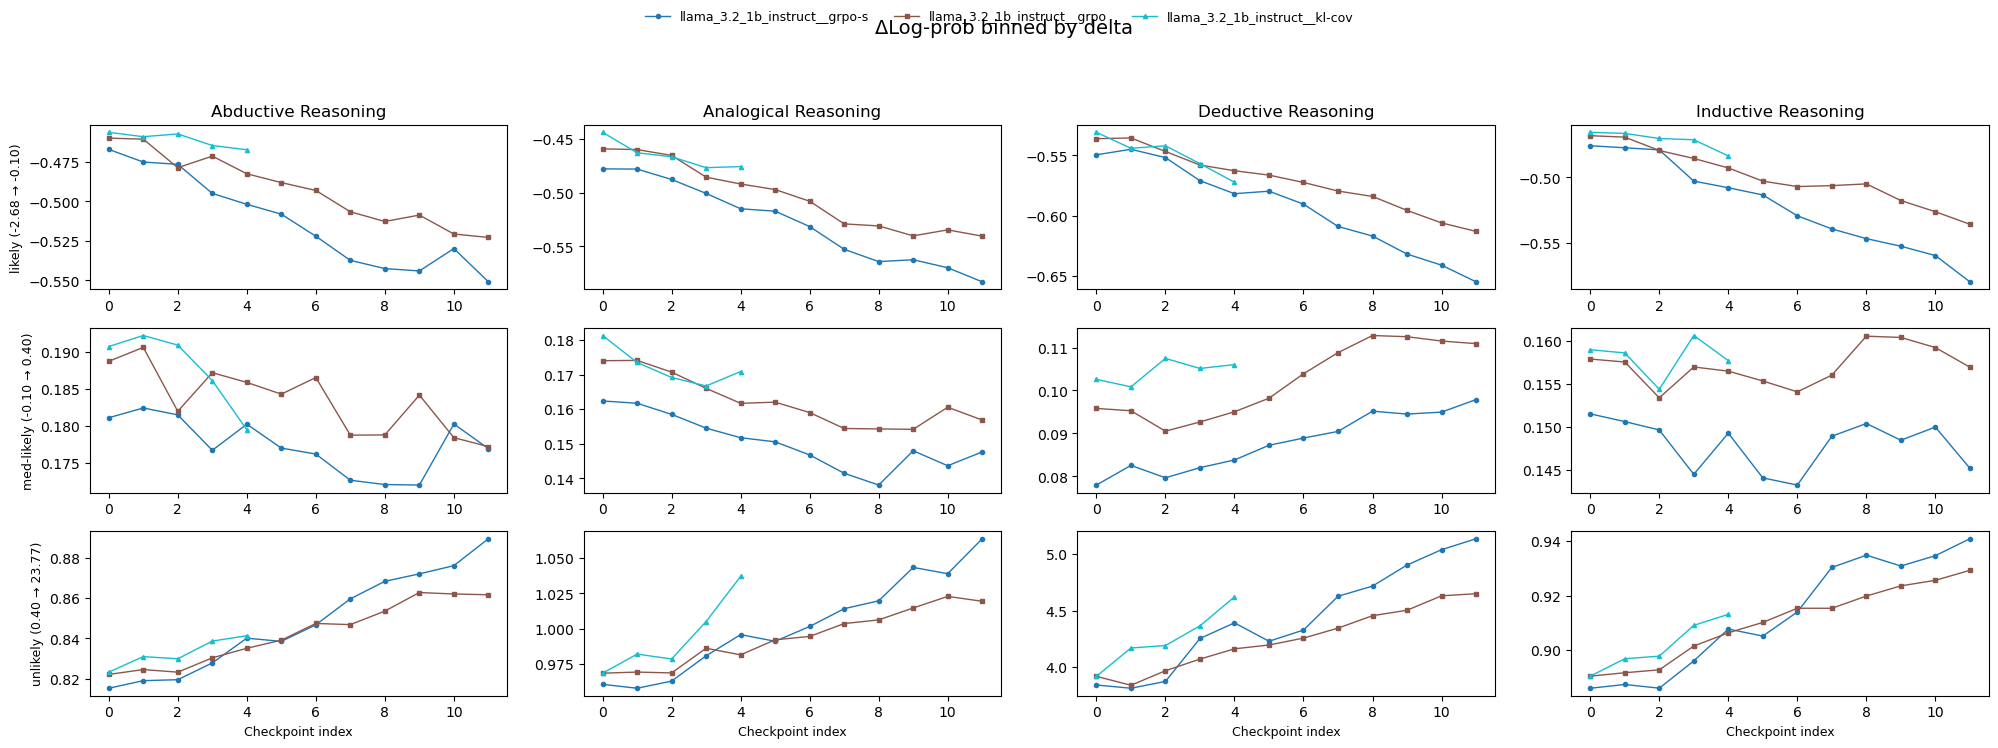

In [18]:
plot_bin(data, by='delta', n_bins=3)

In [19]:
### For class "Decomposition" : take some samples from the likelihood bins and look at whether likelihoods correlate with
# my undertanding of whether the behaviour is applicable...

len(data['llama_3.2_1b_instruct__grpo'])

12

In [20]:
data['llama_3.2_1b_instruct__grpo'][3]['raw']

,behaviour_type,base_lp,lpdelta,entdelta
0,Deductive Reasoning,-0.734587,-0.610978,-1.756264
1,Inductive Reasoning,-0.987170,-0.358395,-2.265336
2,Abductive Reasoning,-1.498031,0.152466,-2.531472
3,Analogical Reasoning,-1.626103,0.280538,-2.746531
4,Deductive Reasoning,-1.275119,-0.596764,-2.474697
...,...,...,...,...
2843,Analogical Reasoning,-1.353565,0.015423,-2.471550
2844,Deductive Reasoning,-1.494476,0.360506,-2.246857
2845,Inductive Reasoning,-1.619541,0.485570,-2.427618
2846,Abductive Reasoning,-2.132880,0.998909,-2.807189


In [26]:
"""
    d is 400 rows = 8 * 50 questions, (7 strategies + 1 anchor) * 50 questions.
    The raw output of the read_data function is 350, as we're dropping the anchors.

    Let's read in the base delta file, delete the anchor rows. Then, we should be able to look at raw prompts. 
"""
reasoning_strats_raw_delta = "/u/rfechner/data/incomplete_reasoning_types/meta-llama--Llama-3.1-8B-Instruct.jsonl-deltas.jsonl"
with open(reasoning_strats_raw_delta, 'r') as file:
    r = pd.read_json(file, lines=True)

In [27]:
r

,prompt,behaviour_type,index
0,"[{'role': 'user', 'content': 'John decides to ...",Deductive Reasoning,0
1,"[{'role': 'user', 'content': 'John decides to ...",Inductive Reasoning,0
2,"[{'role': 'user', 'content': 'John decides to ...",Abductive Reasoning,0
3,"[{'role': 'user', 'content': 'John decides to ...",Analogical Reasoning,0
4,"[{'role': 'user', 'content': 'John decides to ...",anchor,0
...,...,...,...
3555,"[{'role': 'user', 'content': 'Jeremy is drivin...",Deductive Reasoning,711
3556,"[{'role': 'user', 'content': 'Jeremy is drivin...",Inductive Reasoning,711
3557,"[{'role': 'user', 'content': 'Jeremy is drivin...",Abductive Reasoning,711
3558,"[{'role': 'user', 'content': 'Jeremy is drivin...",Analogical Reasoning,711


In [28]:
r = r[r['behaviour_type'] != 'anchor']
r.reset_index(drop=True, inplace=True)
r

,prompt,behaviour_type,index
0,"[{'role': 'user', 'content': 'John decides to ...",Deductive Reasoning,0
1,"[{'role': 'user', 'content': 'John decides to ...",Inductive Reasoning,0
2,"[{'role': 'user', 'content': 'John decides to ...",Abductive Reasoning,0
3,"[{'role': 'user', 'content': 'John decides to ...",Analogical Reasoning,0
4,"[{'role': 'user', 'content': 'Irene earns $500...",Deductive Reasoning,1
...,...,...,...
2843,"[{'role': 'user', 'content': 'Jaydee can type ...",Analogical Reasoning,710
2844,"[{'role': 'user', 'content': 'Jeremy is drivin...",Deductive Reasoning,711
2845,"[{'role': 'user', 'content': 'Jeremy is drivin...",Inductive Reasoning,711
2846,"[{'role': 'user', 'content': 'Jeremy is drivin...",Abductive Reasoning,711


stupid join both dataframes, as we know order is preserved with all previour operations.

In [29]:
processed = data['llama_3.2_1b_instruct__grpo'][0]['raw']
r['lpdelta'] = processed['lpdelta'].copy()
r['base_lp'] = processed['base_lp'].copy()

/tmp/ipykernel_101281/1650014102.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['lpdelta'] = processed['lpdelta'].copy()
/tmp/ipykernel_101281/1650014102.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['base_lp'] = processed['base_lp'].copy()


In [31]:
r.head(2)

,prompt,behaviour_type,index,lpdelta,base_lp
0,"[{'role': 'user', 'content': 'John decides to ...",Deductive Reasoning,0,-0.584732,-0.716056
1,"[{'role': 'user', 'content': 'John decides to ...",Inductive Reasoning,0,-0.316219,-0.984568


In [32]:
# now bin the rows by lpdelta
_min, _max = r['lpdelta'].min(), r['lpdelta'].max()
bins = np.array([-20, -10, -5, -2, -1, 0, 1, 2, 5, 10, 20])# np.linspace(_min, _max, 5)
r['bin'] = r['lpdelta'].apply(lambda x: np.digitize(x, bins=bins))

/tmp/ipykernel_101281/2845262187.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['bin'] = r['lpdelta'].apply(lambda x: np.digitize(x, bins=bins))


In [33]:
r['bin'].unique()

array([ 5,  6,  4,  7, 10,  3, 11,  9])

In [35]:
for name, group in r.groupby('bin', sort=True):
    print('\n\nCurrent Group: ', name, "groupsize: ", len(group), ' Interval: ', bins[max(0, int(name) - 1)], bins[min(len(bins) - 1, int(name))])
    if len(group) == 1:
        print('Behaviour: ', group.iloc[0]['behaviour_type'], " Prompt: \n", group.iloc[0]['prompt'])
        continue
    for i in range(3):
        random_index = np.random.randint(0, len(group) - 1)
        sample = group.iloc[random_index]
        print('Behaviour: ', sample['behaviour_type'], " Prompt: \n", sample['prompt'])



Current Group:  3 groupsize:  2  Interval:  -5 -2
Behaviour:  Abductive Reasoning  Prompt: 
 [{'role': 'user', 'content': 'The Dow Jones Industrial Average fell 2% today. The Dow ended the day at 8,722. What was the Dow in the morning before the markets opened?'}, {'role': 'assistant', 'content': 'The rapid decline in the Dow Jones suggests a significant loss. The simplest explanation is that the Dow fell by 2% of its original value. Testing this hypothesis: if the Dow ended at 8722, then 8722 is 98% of its original value (since 98% of the original value is 98/100 * original value, which equals 8722). If the original value was 100% of itself, then it would be 8722 / 0.98 = 8920. However, this is not the correct original value, since it is not consistent with the fact that the Dow fell 2%. However, if the Dow fell by 2%, then the original value must have been 8722 / 0.98 = 8920 * 0.98 = 8739.18. However, this is not consistent with the given fact that the Dow fell by 2%. However, if t

## Takeaways:

The general trend seems to be holding over model dimension for low-delta likelihood responses. Note: It seems that there are also alot of responses which are degenerate with the llama models. Good news, the degenerate cases seem to be few.